# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## Step 1: Import the Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [1]:
!pip install datasets tiktoken

In [2]:
!pip install -U datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [4]:
print("Dataset files are stored at:", ds.cache_files)




Dataset files are stored at: {'train': [{'filename': '/root/.cache/huggingface/datasets/roneneldan___tiny_stories/default/0.0.0/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/tiny_stories-train-00000-of-00004.arrow'}, {'filename': '/root/.cache/huggingface/datasets/roneneldan___tiny_stories/default/0.0.0/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/tiny_stories-train-00001-of-00004.arrow'}, {'filename': '/root/.cache/huggingface/datasets/roneneldan___tiny_stories/default/0.0.0/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/tiny_stories-train-00002-of-00004.arrow'}, {'filename': '/root/.cache/huggingface/datasets/roneneldan___tiny_stories/default/0.0.0/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/tiny_stories-train-00003-of-00004.arrow'}], 'validation': [{'filename': '/root/.cache/huggingface/datasets/roneneldan___tiny_stories/default/0.0.0/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/tiny_stories-validation.arrow'}]}


### Explore the Dataset

In [5]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [6]:
print("\nFirst example from training split:")
print(ds['train'][0])


First example from training split:
{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}


In [7]:
print("\nFirst example from validation split:")
print(ds['validation'][0])


First example from validation split:
{'text': 'Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."\n\nAfter playing with the car, Kitty and Spot felt thirsty. They found a small pond with clear water. They drank the water and felt very happy. They played together all day and became best friends.'}


## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [5]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")


def process(example):
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    ids = enc.encode_ordinary(example['text'])
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

## Step 3: Create Input-Output batches for the dataset

In [9]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



c:\Work\AI\smollm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the loss function

In [12]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [13]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2

In [17]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.amp.GradScaler(device, enabled=(dtype == 'float16'))

## Step 8: Pre-train the SLM

In [18]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.4037, val loss 9.4111
The current learning rate: 0.00007
Epoch 1000: train loss 8.4553, val loss 8.4607
The current learning rate: 0.00010
Epoch 1500: train loss 7.5181, val loss 7.5176
The current learning rate: 0.00010
Epoch 2000: train loss 6.6820, val loss 6.6791
The current learning rate: 0.00010
Epoch 2500: train loss 5.9903, val loss 5.9849
The current learning rate: 0.00011
Epoch 3000: train loss 5.4854, val loss 5.4806
The current learning rate: 0.00011
Epoch 3500: train loss 5.0552, val loss 5.0538
The current learning rate: 0.00012
Epoch 4000: train loss 4.7343, val loss 4.7337
The current learning rate: 0.00012
Epoch 4500: train loss 4.4846, val loss 4.4885
The current learning rate: 0.00013
Epoch 5000: train loss 4.2745, val loss 4.2796
The current learning rate: 0.00014
Epoch 5500: train loss 4.1095, val loss 4.1089
The current learning rate: 0.00015
Epoch 6000: train loss 3.9614, val loss 3.9596
The current learning rate: 0.00016
Epoch 6500: train

In [19]:
import pandas as pd

# Convert tensors to CPU numbers if they aren't already
train_losses = [loss.item() if hasattr(loss, 'item') else loss for loss in train_loss_list]
val_losses = [loss.item() if hasattr(loss, 'item') else loss for loss in validation_loss_list]

# Create a DataFrame
df_results = pd.DataFrame({
    'epoch': range(eval_iters, (len(train_losses) + 1) * eval_iters, eval_iters),
    'train_loss': train_losses,
    'val_loss': val_losses
})

# Save to CSV
csv_filename = 'training_results.csv'
df_results.to_csv(csv_filename, index=False)

print(f'Results successfully logged to {csv_filename}')
df_results.head()

Results successfully logged to training_results.csv


,epoch,train_loss,val_loss
0,500,9.403674,9.411121
1,1000,8.455320,8.460667
2,1500,7.518111,7.517564
3,2000,6.681978,6.679066
4,2500,5.990329,5.984928


## Step 9: Plot the SLM Loss Function

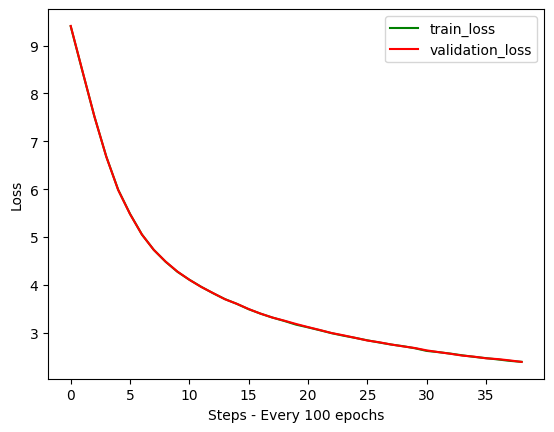

In [20]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



### Overfitting Analysis
We compare the final gap between training and validation loss. A large or growing gap indicates the model is memorizing the training data rather than generalizing.

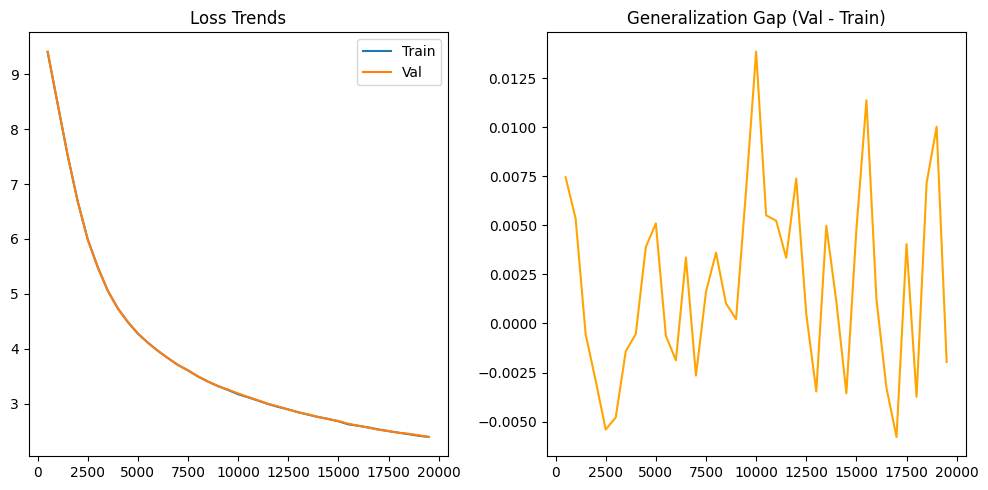

Final Training Loss: 2.3949
Final Validation Loss: 2.3929
Final Gap: -0.0020


In [25]:
import matplotlib.pyplot as plt

# Calculate the gap
df_results['loss_gap'] = df_results['val_loss'] - df_results['train_loss']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(df_results['epoch'], df_results['train_loss'], label='Train')
plt.plot(df_results['epoch'], df_results['val_loss'], label='Val')
plt.title('Loss Trends')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df_results['epoch'], df_results['loss_gap'], color='orange')
plt.title('Generalization Gap (Val - Train)')
plt.tight_layout()
plt.show()

final_gap = df_results['loss_gap'].iloc[-1]
print(f'Final Training Loss: {df_results["train_loss"].iloc[-1]:.4f}')
print(f'Final Validation Loss: {df_results["val_loss"].iloc[-1]:.4f}')
print(f'Final Gap: {final_gap:.4f}')

## Step 10: Run SLM Inference on our trained model

In [3]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [6]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. In the sea, there was a little girl. She smiled with wind songs and colorful ships. She hoped all day.

One day, she saw something strange in the distance. Anna was excited. She wanted to help her family so she followed him. But when she got to the mountain, she saw something blue. It was big and big, a cloud. stole oranges and some were lying on it. She was very sad.

At the end of the day, her parents took the turkey away and made her feel less sleepy. Anna decided to take it back to her family and told her not she needed to hide. She tried toese to stop her daughter and go with her dad.

The party was far away - every morning to trip, Anna.Once upon a time, there was a big, strong swamp was a big and she lived by a river. All the other animals knew that she had to have fun using her surroundings. They had a big best week


In [23]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods. As they crept closer and braches, T worlds were so excited and couldn't stop. 

The little girl had already found the little girl to scare the fox from the mountain. The kind woman was still wearing her pocket full reminder of her own head grateful she had forget and no one in fear.Once upon a time, there was a little boy named Timmy. Timmy loved arrows by his daughter's tune. One day, his grandma came to play with a butterfly. She was so happy and asked, "Mommy, can I dive next to the tree?" The butterfly said yes but she was too fast.

Timmy started to kick the butterfly, and it flew all over. In the hole he went, he spotted a big hungry butterfly with a rock. The bunny hopped with relief and said, "Hi, little bunny. It's so dry!" 

The butterfly jumped for a while, and the butterfly started to dive. The butterfly felt


In [24]:
sentence = "There was a boy.."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

There was a boy.. Hank. He had a bag that could put all of the food in the body and he saw loud noises. He also made the gate just like it was gone.

Today suddenly the park passed! It was a scarf. He was so surprised to discover the man that he asked "What do you want?"

The boy was curious, and he thought for a moment. But the urge said, "Let's come inside."

The boy was so happy as he went home with his family and were walking back home for a walk in the forest. Suddenly, he heard her. She was so excited and stepped inside to find a tree. She walked up to the tree and said, "Are you?"

The tree first knot through the forest, in holes, looking. Suddenly, he heard a voice coming from inside. It was a hunter with a question!

The hunter spent the dark weeks with her food, and was very happy. From that day of the


## Some more experinments



### Experiment: Gradient and Weight Distribution
This helps ensure that the model is learning effectively across all layers and that gradients are flowing properly.

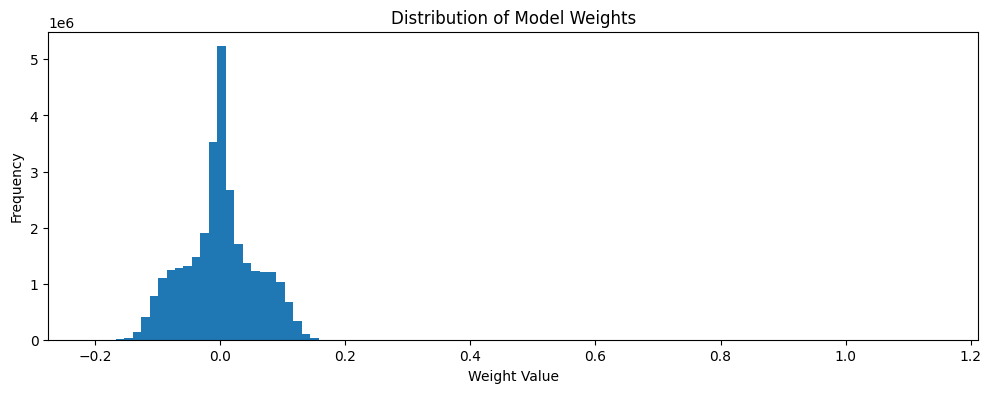

In [26]:
def plot_model_stats(model):
    weights = []
    for p in model.parameters():
        weights.append(p.view(-1).detach().cpu().numpy())

    plt.figure(figsize=(12, 4))
    plt.hist(np.concatenate(weights), bins=100)
    plt.title('Distribution of Model Weights')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.show()

plot_model_stats(model)

## Experimental Framework: SLM Optimization

To improve our Small Language Model, we can systematically test three key areas:

### 1. Hyperparameter Tuning
- **Learning Rate**: A higher LR (e.g., 5e-4) might converge faster but can be unstable. A lower LR (e.g., 5e-5) is safer but slow.
- **Batch Size**: Larger batches provide smoother gradient updates but require more GPU memory.

### 2. Regularization
- **Dropout**: Adding dropout (e.g., 0.1 to 0.2) forces the network to learn redundant representations, reducing the 'Generalization Gap' we saw earlier.
- **Weight Decay**: Penalizes large weights to keep the model simple and prevent overfitting.

### 3. Architecture Variations
- **Activation Functions**: While GELU is standard, **SwiGLU** often yields better performance in modern LLMs.
- **Heads & Embedding**: Adjusting `n_head` while keeping `n_embd` constant changes how the model attends to different parts of the context without significantly increasing parameter count.

In [ ]:
class SwiGLU(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.w1 = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.w2 = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.w3 = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)

    def forward(self, x):
        return self.w3(F.silu(self.w1(x)) * self.w2(x))

# Updated MLP block to allow switching between GELU and SwiGLU
class ExperimentalMLP(nn.Module):
    def __init__(self, config, use_swiglu=False):
        super().__init__()
        if use_swiglu:
            self.net = SwiGLU(config)
        else:
            self.net = nn.Sequential(
                nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias),
                nn.GELU(),
                nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias),
                nn.Dropout(config.dropout)
            )
    def forward(self, x):
        return self.net(x)

print("Experimental components (SwiGLU) defined. You can now re-initialize the GPT model with these blocks.")

### Running an Experiment

Use the code below to run a 'mini-experiment' with a specific configuration (e.g., higher dropout and SwiGLU activation).

In [ ]:
# Example: Experimenting with higher regularization and SwiGLU
exp_config = GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=8,       # Increased heads
    n_embd=384,
    dropout=0.2,     # Higher dropout for regularization
    bias=True
)

exp_model = GPT(exp_config).to(device)
# Note: You would then re-run the training loop defined in Step 8 with this 'exp_model'
print(f"Experimental model initialized with {sum(p.numel() for p in exp_model.parameters())/1e6:.2f}M parameters.")